# Graph Optimal Transport Experiment

We perform a classification experiment for a synthetic dataset of distributions defined over graphs.

In [1]:
import numpy as np
import networkx as nx
import ot
import matplotlib.pyplot as plt
import time
from ObservableWasserstein import *
import random

In [2]:
def nearest_classification(D,num_samples_per_class,labels):
    
    score = np.sum(np.floor(np.argsort(D,axis=1)/num_samples_per_class)[:,1] == labels)
    
    return score/len(labels)

## Base Graph

In this experiment, we'll work with Observable Wasserstein distance defined over a graph. Let's pick a base graph to define distributions over.

In [3]:
random_seed = 100
G = nx.random_geometric_graph(100, 0.2, seed = random_seed)
pos = {n:G.nodes[n]['pos'] for n in G.nodes}

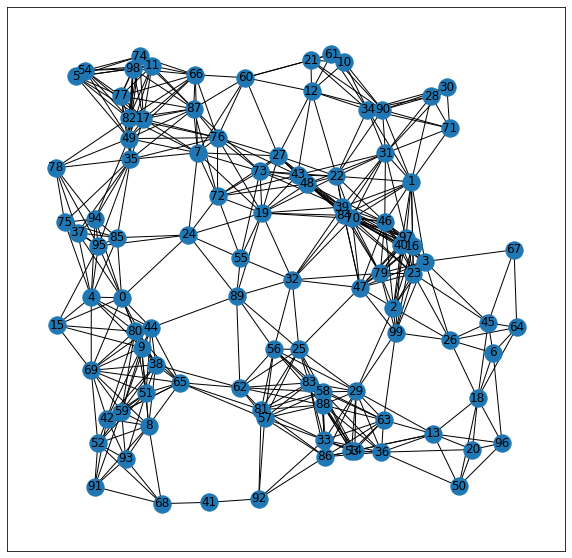

In [4]:
plt.figure(figsize = (10,10))
nx.draw_networkx(G,pos = pos)

## Computing Wasserstein Distance

We can compute the classical Wasserstein distance between a pair of distributions. This requires computing the full distance matrix for the graph.

In [6]:
def compute_Wasserstein_distance(G,mu1,mu2):
    
    C = nx.floyd_warshall_numpy(G)
    dist = ot.emd2(mu1,mu2,C)
    
    return dist

## Computing Observable Wasserstein Distance

We need code to compute the anchor distances, from a subset of nodes to all other nodes in the graph.

In [10]:
def distances_from_sources_unweighted(G, sources, nodelist=None):
    if nodelist is None:
        nodelist = list(G.nodes())
    idx = {v:i for i,v in enumerate(nodelist)}

    D = np.full((len(sources), len(nodelist)), np.inf, dtype=float)

    for r, s in enumerate(sources):
        lengths = nx.single_source_shortest_path_length(G, s)  # BFS
        for v, d in lengths.items():
            D[r, idx[v]] = d
    return D


Using the above, we can compute observable Wasserstein distances.

In [13]:
def observable_wasserstein_distance(anchor_distancesX,anchor_distancesY,weightsX=None,weightsY=None,expectation_version = False):

    distances = []

    n = len(anchor_distancesX)

    for j in range(n):

        dist = emd(anchor_distancesX[j,:],anchor_distancesY[j,:],a=weightsX,b=weightsY)
        distances.append(dist)

    if expectation_version:
        return np.mean(distances)
    else:
        return max(distances)

In [15]:
def compute_observable_Wasserstein_distance(G,mu1,mu2,num_anchor_nodes):
    
    sources = random.sample(G.nodes, num_anchor_nodes)
    anchor_distances = distances_from_sources_unweighted(G,sources)
    dist = observable_wasserstein_distance(anchor_distances,anchor_distances,mu1,mu2)
    
    return dist

### Distributions

We now define a parametric family of distributions over a given geometric graph.

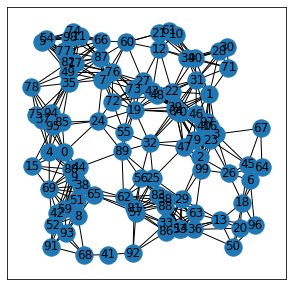

In [168]:
random_seed = 100
G = nx.random_geometric_graph(100, 0.2, seed = random_seed)
pos = {n:G.nodes[n]['pos'] for n in G.nodes}

plt.figure(figsize = (5,5))
nx.draw_networkx(G,pos = pos)

The idea is to randomly choose a node from a given 'geographic region', such as 'top left' or 'bottom right' (this region is a parameter). Then we run heat diffusion from that node for a given amount of time, add a specified amount of noise (a multiple of the max value of the heat function), then renormalize. 

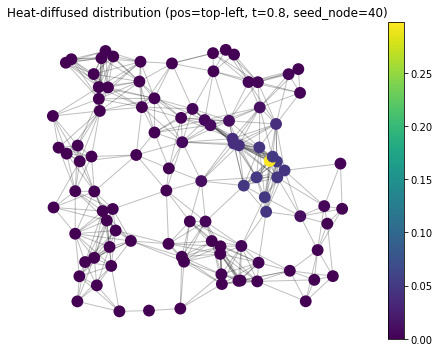

In [192]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

from scipy.sparse.linalg import expm_multiply

# ------------------------------------------------------------
# 4x4 grid utilities
# ------------------------------------------------------------
def grid4x4_indices(pos, node, eps=1e-12):
    """
    Return (row, col) in {0,1,2,3}x{0,1,2,3} for a node based on its (x,y).
    row=0 is bottom, row=3 is top. col=0 is left, col=3 is right.
    """
    nodes = list(pos.keys())
    XY = np.array([pos[n] for n in nodes], dtype=float)
    xs, ys = XY[:, 0], XY[:, 1]

    xmin, xmax = xs.min(), xs.max()
    ymin, ymax = ys.min(), ys.max()

    x, y = pos[node]
    # Normalize into [0,1]
    xn = (x - xmin) / (xmax - xmin + eps)
    yn = (y - ymin) / (ymax - ymin + eps)

    col = int(np.clip(np.floor(4 * xn), 0, 3))
    row = int(np.clip(np.floor(4 * yn), 0, 3))
    return row, col


def nodes_in_grid_cell(pos, row, col):
    """All nodes whose positions fall in a specific (row, col) cell of the 4x4 grid."""
    out = []
    for n in pos:
        r, c = grid4x4_indices(pos, n)
        if r == row and c == col:
            out.append(n)
    return out


def candidate_nodes_for_position(pos, position):
    """
    position ∈ {'top-left','middle','bottom-right'}.

    - top-left: (row=3, col=0)
    - bottom-right: (row=0, col=3)
    - middle: union of the 2x2 central cells {(1,1),(1,2),(2,1),(2,2)}
    """
    position = position.lower()
    if position in ["top-left", "topleft", "top_left"]:
        return nodes_in_grid_cell(pos, row=3, col=0)

    if position in ["bottom-right", "bottomright", "bottom_right"]:
        return nodes_in_grid_cell(pos, row=0, col=3)

    if position == "middle":
        mids = []
        for r in [1, 2]:
            for c in [1, 2]:
                mids.extend(nodes_in_grid_cell(pos, row=r, col=c))
        return mids

    raise ValueError("position must be one of: 'top-left', 'middle', 'bottom-right'.")


# ------------------------------------------------------------
# Heat diffusion distribution
# ------------------------------------------------------------
def heat_diffusion_distribution(G, pos, position="top-left", time=1.0, noise_level=0, seed=None):
    """
    1) Partition the node positions into a 4x4 grid.
    2) Pick a node uniformly at random from the requested region:
          top-left, middle, bottom-right
    3) Run heat diffusion for given 'time' centered at that node:
          u(t) = exp(-t * L) delta_seed
       where L is the (combinatorial) graph Laplacian.
    4) Normalize u(t) to a probability distribution on nodes.

    Returns:
      p: np.ndarray shape (n_nodes,) in node order `nodelist`
      chosen_node: the seed node used
      nodelist: list of nodes corresponding to entries of p
    """
    if time <= 0:
        raise ValueError("time must be a positive number.")

    rng = np.random.default_rng(seed)

    candidates = candidate_nodes_for_position(pos, position)
    if len(candidates) == 0:
        raise RuntimeError(
            f"No nodes found in region '{position}' using the 4x4 grid. "
            "Try a different random_seed, larger radius, or use position='middle'."
        )

    chosen_node = rng.choice(candidates)

    nodelist = list(G.nodes())
    idx = {v: i for i, v in enumerate(nodelist)}
    n = len(nodelist)

    # Laplacian (sparse) in the chosen node order
    # (Works in both older/newer NetworkX versions)
    try:
        L = nx.laplacian_matrix(G, nodelist=nodelist)  # scipy sparse
    except TypeError:
        L = nx.laplacian_matrix(G)  # older signatures

    # Initial heat: delta at chosen node
    delta = np.zeros(n, dtype=float)
    delta[idx[chosen_node]] = 1.0

    # Heat diffusion: u = exp(-time * L) delta
    u = expm_multiply((-time) * L, delta)
    u += noise_level*np.max(u)*np.random.rand(len(u))

    # Numerical cleanup + normalize to probability distribution
    u = np.maximum(u, 0.0)
    s = u.sum()
    if s <= 0:
        raise RuntimeError("Heat diffusion produced zero mass (unexpected).")
    p = u / s

    return p, chosen_node, nodelist


# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------
def plot_distribution_on_graph(
    G, pos, p, nodelist=None, ax=None, title=None,
    node_size=140, with_edges=True, edge_alpha=0.25,
    cmap="viridis", vmin=0.0, vmax=None, colorbar=True
):
    """
    Plot a probability distribution p as a node heatmap.
    p should be aligned with nodelist (default: G.nodes()).
    """
    if nodelist is None:
        nodelist = list(G.nodes())

    # Align p to G.nodes() order if needed
    if nodelist != list(G.nodes()):
        idx = {v: i for i, v in enumerate(nodelist)}
        values = np.array([p[idx[v]] for v in G.nodes()], dtype=float)
    else:
        values = np.asarray(p, dtype=float)

    if vmax is None:
        vmax = float(values.max())

    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    cmap_obj = cm.get_cmap(cmap)
    node_colors = cmap_obj(norm(values))

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    if with_edges:
        nx.draw_networkx_edges(G, pos, ax=ax, alpha=edge_alpha)

    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_color=node_colors,
        node_size=node_size,
        linewidths=0.0,
    )

    ax.set_axis_off()
    if title:
        ax.set_title(title)

    sm = cm.ScalarMappable(norm=norm, cmap=cmap_obj)
    sm.set_array([])
    
    if colorbar:
        plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
        
    plt.tight_layout()
    
    return ax


# ------------------------------------------------------------
# Example usage
# ------------------------------------------------------------
if __name__ == "__main__":
    random_seed = 100
    G = nx.random_geometric_graph(100, 0.2, seed=random_seed)
    pos = {n: G.nodes[n]["pos"] for n in G.nodes}

    p, seed_node, nodelist = heat_diffusion_distribution(
        G, pos, position="middle", time=0.1
    )

    plot_distribution_on_graph(
        G, pos, p, nodelist=nodelist,
        title=f"Heat-diffused distribution (pos=top-left, t=0.8, seed_node={seed_node})"
    )
    plt.tight_layout()
    plt.show()


The following generates a dataset of distributions over a fixed graph, with classes determined by 'geographic location'.

In [47]:
def generate_three_class_dataset(G,pos,num_per_class,time,noise_level=0,return_log=False):
    
    P = []
    labels = num_per_class*[0]+num_per_class*[1]+num_per_class*[2]
    log = {}
    log['seed_node'] = []
    log['nodelist'] = []
    
    for j in range(num_per_class):
        p, seed_node, nodelist = heat_diffusion_distribution(G, pos, position="top-left",noise_level=noise_level, time=time)
        P.append(p)
        log['seed_node'].append(seed_node)
        log['nodelist'].append(nodelist)
        
    for j in range(num_per_class):
        p, seed_node, nodelist = heat_diffusion_distribution(G, pos, position="middle",noise_level=noise_level, time=time)
        P.append(p)
        log['seed_node'].append(seed_node)
        log['nodelist'].append(nodelist)
        
    for j in range(num_per_class):
        p, seed_node, nodelist = heat_diffusion_distribution(G, pos, position="bottom-right",noise_level=noise_level, time=time)
        P.append(p)
        log['seed_node'].append(seed_node)
        log['nodelist'].append(nodelist)
        
    if return_log:
        return P, labels, log
    else:
        return P, labels

In [222]:
graph_size = 250
n=graph_size
radius = np.sqrt(np.log(n)/(n))
t = .01*n

G = nx.random_geometric_graph(graph_size, radius)
pos = {n: G.nodes[n]["pos"] for n in G.nodes}

n_per_class = 2
noise_level= 1.5

P, labels, log = generate_three_class_dataset(G,pos,n_per_class,t,noise_level = noise_level,return_log = True)

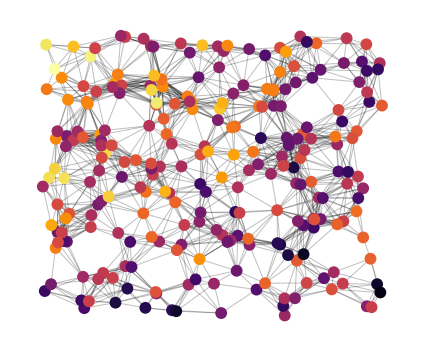

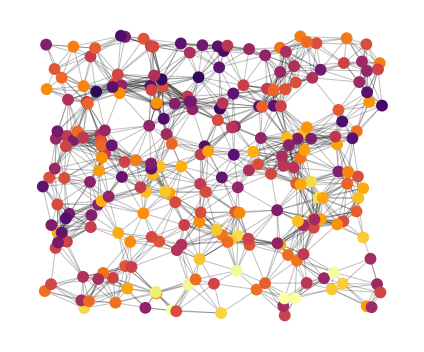

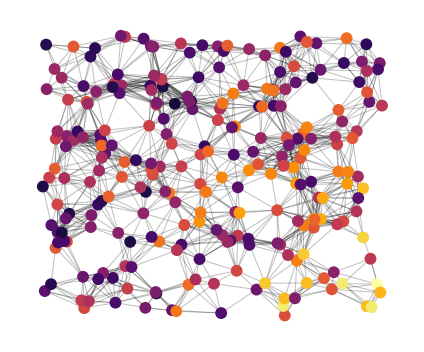

In [223]:
idx_to_plot = [1,3,5]

for idx in idx_to_plot:

    p = P[idx]
    nodelist = log['nodelist'][idx]

    plot_distribution_on_graph(G, pos, p, nodelist=nodelist, cmap="inferno", colorbar=False)
    plt.savefig(f"distribution_on_graph_{idx}.png",dpi=300)

## Classification Experiment

Now we test the ability of the various metrics to classify distributions on graphs, as described above.

In [224]:
import numpy as np
import time
import networkx as nx

# -----------------------------
# User parameters (as you had)
# -----------------------------
graph_sizes = [100,250,500]
n_per_class = 10
num_graph_runs = 10
num_runs_per_graph = 2  # (kept for compatibility; not used in your original loop)
noise_levels = [0.5,1.0, 1.5, 2.0,2.5,3.0]
num_slices_percentages = [0.05, 0.1, 0.15]

# -----------------------------
# Results container
# -----------------------------
# results[graph_size]["wass class mean"][noise_level] = ...
# results[graph_size]["obs class mean"][num_slices_percentage][noise_level] = ...
results = {}

for graph_size in graph_sizes:
    print("=====================")
    print("Starting graph size", graph_size)
    print("=====================")

    results[graph_size] = {}

    radius = np.sqrt(np.log(n)/(n))
    t = .01*n

    # Collect per-noise lists (so we can summarize by noise later)
    wass_class_scores = {nl: [] for nl in noise_levels}
    wass_times = {nl: [] for nl in noise_levels}

    obs_class_scores = {
        p: {nl: [] for nl in noise_levels} for p in num_slices_percentages
    }
    obs_times = {
        p: {nl: [] for nl in noise_levels} for p in num_slices_percentages
    }

    for graph_run in range(num_graph_runs):
        print("----------------------")
        print("Starting graph run", graph_run)
        print("----------------------")
        
        connected_flag = False
        
        count = 0
        
        while connected_flag == False and count < 100:
            
            G = nx.random_geometric_graph(graph_size, radius)
            connected_flag = nx.is_connected(G)
            count += 1
            
        if connected_flag == False:
            raise('Graph not connected')
        
        pos = {n: G.nodes[n]["pos"] for n in G.nodes}

        for noise_level in noise_levels:
            print(f"Noise level {noise_level}: generating dataset...")
            P, labels, log = generate_three_class_dataset(
                G, pos, n_per_class, t, noise_level=noise_level, return_log=True
            )

            # -----------------------------
            # Wasserstein classification
            # -----------------------------
            print(f"Wasserstein classification (noise={noise_level})")
            start = time.time()

            dists = np.zeros((len(P), len(P)))
            for i in range(len(P)):
                mu1 = P[i]
                for j in range(i + 1, len(P)):
                    mu2 = P[j]
                    dists[i, j] = compute_Wasserstein_distance(G, mu1, mu2)
            dists = dists + dists.T

            score = nearest_classification(dists, n_per_class, labels)
            elapsed = time.time() - start

            wass_class_scores[noise_level].append(score)
            wass_times[noise_level].append(elapsed)

            print(f"  -> score={score:.4f}, time={elapsed:.3f}s")

            # -----------------------------
            # Observable Wasserstein classification
            # (one run per slice percentage)
            # -----------------------------
            print(f"Observable classification (noise={noise_level})")
            for p in num_slices_percentages:
                num_anchor_nodes = int(max(p * graph_size, 1))
                print(f"  slices={p:.2%} (anchors={num_anchor_nodes})")

                start = time.time()

                dists = np.zeros((len(P), len(P)))
                for i in range(len(P)):
                    mu1 = P[i]
                    for j in range(i + 1, len(P)):
                        mu2 = P[j]
                        dists[i, j] = compute_observable_Wasserstein_distance(
                            G, mu1, mu2, num_anchor_nodes
                        )
                dists = dists + dists.T

                score = nearest_classification(dists, n_per_class, labels)
                elapsed = time.time() - start

                obs_class_scores[p][noise_level].append(score)
                obs_times[p][noise_level].append(elapsed)

                print(f"    -> score={score:.4f}, time={elapsed:.3f}s")

    # -----------------------------
    # Summaries into results dict
    # -----------------------------
    results[graph_size]["wass class mean"] = {
        nl: float(np.mean(wass_class_scores[nl])) for nl in noise_levels
    }
    results[graph_size]["wass class std"] = {
        nl: float(np.std(wass_class_scores[nl])) for nl in noise_levels
    }
    results[graph_size]["wass time mean"] = {
        nl: float(np.mean(wass_times[nl])) for nl in noise_levels
    }
    results[graph_size]["wass time std"] = {
        nl: float(np.std(wass_times[nl])) for nl in noise_levels
    }

    results[graph_size]["obs class mean"] = {}
    results[graph_size]["obs class std"] = {}
    results[graph_size]["obs time mean"] = {}
    results[graph_size]["obs time std"] = {}

    for p in num_slices_percentages:
        results[graph_size]["obs class mean"][p] = {
            nl: float(np.mean(obs_class_scores[p][nl])) for nl in noise_levels
        }
        results[graph_size]["obs class std"][p] = {
            nl: float(np.std(obs_class_scores[p][nl])) for nl in noise_levels
        }
        results[graph_size]["obs time mean"][p] = {
            nl: float(np.mean(obs_times[p][nl])) for nl in noise_levels
        }
        results[graph_size]["obs time std"][p] = {
            nl: float(np.std(obs_times[p][nl])) for nl in noise_levels
        }

    # Optional end-of-size summary printout
    print("==== Summary for graph size", graph_size, "====")
    for nl in noise_levels:
        print(
            f"  Wass   (noise={nl}): "
            f"class={results[graph_size]['wass class mean'][nl]:.4f}±{results[graph_size]['wass class std'][nl]:.4f}, "
            f"time={results[graph_size]['wass time mean'][nl]:.3f}±{results[graph_size]['wass time std'][nl]:.3f}s"
        )
        for p in num_slices_percentages:
            print(
                f"  Obs {p:.2%} (noise={nl}): "
                f"class={results[graph_size]['obs class mean'][p][nl]:.4f}±{results[graph_size]['obs class std'][p][nl]:.4f}, "
                f"time={results[graph_size]['obs time mean'][p][nl]:.3f}±{results[graph_size]['obs time std'][p][nl]:.3f}s"
            )
    print("=============================================")


Starting graph size 100
----------------------
Starting graph run 0
----------------------
Noise level 0.5: generating dataset...
Wasserstein classification (noise=0.5)
  -> score=0.9667, time=1.687s
Observable classification (noise=0.5)
  slices=5.00% (anchors=5)
    -> score=0.9667, time=0.684s
  slices=10.00% (anchors=10)
    -> score=0.9333, time=1.323s
  slices=15.00% (anchors=15)
    -> score=0.9667, time=1.938s
Noise level 1.0: generating dataset...
Wasserstein classification (noise=1.0)
  -> score=0.9667, time=1.610s
Observable classification (noise=1.0)
  slices=5.00% (anchors=5)
    -> score=0.9667, time=0.679s
  slices=10.00% (anchors=10)
    -> score=0.9333, time=1.311s
  slices=15.00% (anchors=15)
    -> score=0.9667, time=1.952s
Noise level 1.5: generating dataset...
Wasserstein classification (noise=1.5)
  -> score=0.9333, time=1.605s
Observable classification (noise=1.5)
  slices=5.00% (anchors=5)
    -> score=0.8667, time=0.664s
  slices=10.00% (anchors=10)
    -> scor

    -> score=0.9000, time=1.883s
----------------------
Starting graph run 4
----------------------
Noise level 0.5: generating dataset...
Wasserstein classification (noise=0.5)
  -> score=0.9667, time=1.588s
Observable classification (noise=0.5)
  slices=5.00% (anchors=5)
    -> score=1.0000, time=0.658s
  slices=10.00% (anchors=10)
    -> score=1.0000, time=1.276s
  slices=15.00% (anchors=15)
    -> score=0.9667, time=1.890s
Noise level 1.0: generating dataset...
Wasserstein classification (noise=1.0)
  -> score=1.0000, time=1.608s
Observable classification (noise=1.0)
  slices=5.00% (anchors=5)
    -> score=1.0000, time=0.659s
  slices=10.00% (anchors=10)
    -> score=1.0000, time=1.274s
  slices=15.00% (anchors=15)
    -> score=1.0000, time=1.887s
Noise level 1.5: generating dataset...
Wasserstein classification (noise=1.5)
  -> score=1.0000, time=1.595s
Observable classification (noise=1.5)
  slices=5.00% (anchors=5)
    -> score=1.0000, time=0.665s
  slices=10.00% (anchors=10)
  

    -> score=0.7000, time=1.882s
----------------------
Starting graph run 8
----------------------
Noise level 0.5: generating dataset...
Wasserstein classification (noise=0.5)
  -> score=1.0000, time=1.589s
Observable classification (noise=0.5)
  slices=5.00% (anchors=5)
    -> score=1.0000, time=0.661s
  slices=10.00% (anchors=10)
    -> score=1.0000, time=1.295s
  slices=15.00% (anchors=15)
    -> score=1.0000, time=2.231s
Noise level 1.0: generating dataset...
Wasserstein classification (noise=1.0)
  -> score=1.0000, time=1.591s
Observable classification (noise=1.0)
  slices=5.00% (anchors=5)
    -> score=1.0000, time=0.660s
  slices=10.00% (anchors=10)
    -> score=1.0000, time=1.277s
  slices=15.00% (anchors=15)
    -> score=1.0000, time=1.885s
Noise level 1.5: generating dataset...
Wasserstein classification (noise=1.5)
  -> score=1.0000, time=1.587s
Observable classification (noise=1.5)
  slices=5.00% (anchors=5)
    -> score=1.0000, time=0.665s
  slices=10.00% (anchors=10)
  

    -> score=0.9667, time=9.677s
Noise level 1.0: generating dataset...
Wasserstein classification (noise=1.0)
  -> score=1.0000, time=17.644s
Observable classification (noise=1.0)
  slices=5.00% (anchors=12)
    -> score=1.0000, time=2.899s
  slices=10.00% (anchors=25)
    -> score=0.9667, time=6.405s
  slices=15.00% (anchors=37)
    -> score=1.0000, time=8.914s
Noise level 1.5: generating dataset...
Wasserstein classification (noise=1.5)
  -> score=0.8000, time=17.175s
Observable classification (noise=1.5)
  slices=5.00% (anchors=12)
    -> score=0.8000, time=2.906s
  slices=10.00% (anchors=25)
    -> score=0.8667, time=6.018s
  slices=15.00% (anchors=37)
    -> score=0.8000, time=9.017s
Noise level 2.0: generating dataset...
Wasserstein classification (noise=2.0)
  -> score=0.8000, time=17.371s
Observable classification (noise=2.0)
  slices=5.00% (anchors=12)
    -> score=0.7667, time=2.926s
  slices=10.00% (anchors=25)
    -> score=0.7667, time=5.935s
  slices=15.00% (anchors=37)
 

    -> score=1.0000, time=5.924s
  slices=15.00% (anchors=37)
    -> score=1.0000, time=8.828s
Noise level 1.0: generating dataset...
Wasserstein classification (noise=1.0)
  -> score=0.9333, time=16.958s
Observable classification (noise=1.0)
  slices=5.00% (anchors=12)
    -> score=0.9000, time=2.804s
  slices=10.00% (anchors=25)
    -> score=0.9000, time=5.790s
  slices=15.00% (anchors=37)
    -> score=0.9000, time=8.531s
Noise level 1.5: generating dataset...
Wasserstein classification (noise=1.5)
  -> score=0.9333, time=16.718s
Observable classification (noise=1.5)
  slices=5.00% (anchors=12)
    -> score=0.8667, time=2.809s
  slices=10.00% (anchors=25)
    -> score=0.8667, time=5.793s
  slices=15.00% (anchors=37)
    -> score=0.9333, time=8.695s
Noise level 2.0: generating dataset...
Wasserstein classification (noise=2.0)
  -> score=0.8667, time=17.119s
Observable classification (noise=2.0)
  slices=5.00% (anchors=12)
    -> score=0.9000, time=3.379s
  slices=10.00% (anchors=25)
 

    -> score=0.9333, time=2.876s
  slices=10.00% (anchors=25)
    -> score=0.9667, time=5.858s
  slices=15.00% (anchors=37)
    -> score=0.9667, time=8.855s
Noise level 1.0: generating dataset...
Wasserstein classification (noise=1.0)
  -> score=0.9667, time=16.761s
Observable classification (noise=1.0)
  slices=5.00% (anchors=12)
    -> score=0.9667, time=2.886s
  slices=10.00% (anchors=25)
    -> score=0.9667, time=6.055s
  slices=15.00% (anchors=37)
    -> score=0.9667, time=9.104s
Noise level 1.5: generating dataset...
Wasserstein classification (noise=1.5)
  -> score=0.9667, time=17.285s
Observable classification (noise=1.5)
  slices=5.00% (anchors=12)
    -> score=0.9667, time=2.961s
  slices=10.00% (anchors=25)
    -> score=0.9667, time=6.156s
  slices=15.00% (anchors=37)
    -> score=0.9667, time=8.972s
Noise level 2.0: generating dataset...
Wasserstein classification (noise=2.0)
  -> score=0.9667, time=17.598s
Observable classification (noise=2.0)
  slices=5.00% (anchors=12)
 

    -> score=0.9333, time=12.288s
  slices=10.00% (anchors=50)
    -> score=0.9000, time=24.499s
  slices=15.00% (anchors=75)
    -> score=0.9333, time=34.931s
Noise level 1.5: generating dataset...
Wasserstein classification (noise=1.5)
  -> score=0.9000, time=170.254s
Observable classification (noise=1.5)
  slices=5.00% (anchors=25)
    -> score=0.9000, time=12.679s
  slices=10.00% (anchors=50)
    -> score=0.8667, time=25.441s
  slices=15.00% (anchors=75)
    -> score=0.9333, time=35.540s
Noise level 2.0: generating dataset...
Wasserstein classification (noise=2.0)
  -> score=0.9667, time=169.440s
Observable classification (noise=2.0)
  slices=5.00% (anchors=25)
    -> score=0.9333, time=12.788s
  slices=10.00% (anchors=50)
    -> score=0.9333, time=24.292s
  slices=15.00% (anchors=75)
    -> score=0.9333, time=40.274s
Noise level 2.5: generating dataset...
Wasserstein classification (noise=2.5)
  -> score=0.8333, time=149.230s
Observable classification (noise=2.5)
  slices=5.00% (a

Wasserstein classification (noise=1.0)
  -> score=0.9667, time=127.876s
Observable classification (noise=1.0)
  slices=5.00% (anchors=25)
    -> score=0.9667, time=10.704s
  slices=10.00% (anchors=50)
    -> score=0.9667, time=21.264s
  slices=15.00% (anchors=75)
    -> score=0.9667, time=31.870s
Noise level 1.5: generating dataset...
Wasserstein classification (noise=1.5)
  -> score=0.9333, time=127.509s
Observable classification (noise=1.5)
  slices=5.00% (anchors=25)
    -> score=0.9000, time=10.699s
  slices=10.00% (anchors=50)
    -> score=0.9000, time=21.273s
  slices=15.00% (anchors=75)
    -> score=0.9000, time=31.842s
Noise level 2.0: generating dataset...
Wasserstein classification (noise=2.0)
  -> score=0.8333, time=122.825s
Observable classification (noise=2.0)
  slices=5.00% (anchors=25)
    -> score=0.8667, time=10.553s
  slices=10.00% (anchors=50)
    -> score=0.9000, time=20.823s
  slices=15.00% (anchors=75)
    -> score=0.9000, time=31.154s
Noise level 2.5: generating 

In [225]:
import pickle

with open('GraphResults_NewExperiment_Version2.pkl', 'wb') as f: # Open file in write binary ('wb') mode
    pickle.dump(results, f)

Plotting the results

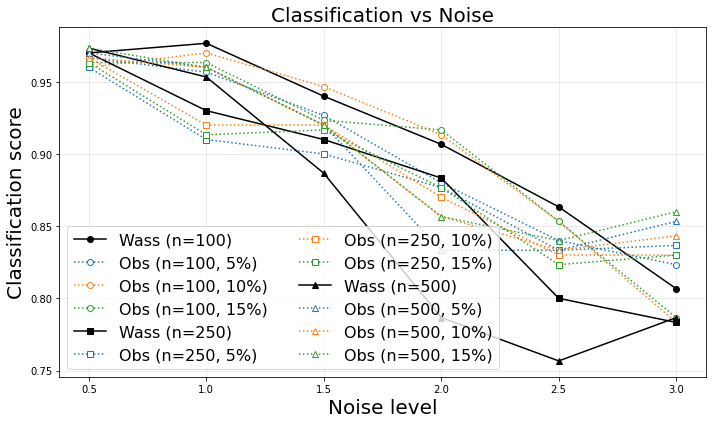

In [226]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.figure(figsize=figsize)

fontsize = 20

# Marker per graph size
marker_cycle = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', '<', '>', 'h', 'p']
markers = {gs: marker_cycle[i % len(marker_cycle)]
           for i, gs in enumerate(graph_sizes)}

# Color per slice percentage
cmap = plt.get_cmap("tab10")
slice_colors = {p: cmap(i % 10)
                for i, p in enumerate(num_slices_percentages)}

for gs in graph_sizes:
    m = markers[gs]
    x = noise_levels

    # --- Wasserstein (solid, black) ---
    y_wass = [results[gs]["wass class mean"][nl] for nl in x]

    plt.plot(
        x, y_wass,
        linestyle="-",
        marker=m,
        color="black",
        markerfacecolor="black",
        markeredgecolor="black",
        label=f"Wass (n={gs})"
    )

    # --- Observable (dotted, colored by slice %) ---
    for p in num_slices_percentages:
        y_obs = [results[gs]["obs class mean"][p][nl] for nl in x]
        c = slice_colors[p]

        plt.plot(
            x, y_obs,
            linestyle=":",
            marker=m,
            color=c,
            markerfacecolor="white",
            markeredgecolor=c,
            label=f"Obs (n={gs}, {p:.0%})"
        )

plt.xlabel("Noise level", fontsize=fontsize)
plt.ylabel("Classification score", fontsize=fontsize)
plt.title("Classification vs Noise", fontsize=fontsize)
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=16)
plt.tight_layout()
plt.show()



Plotting the results on separate axes

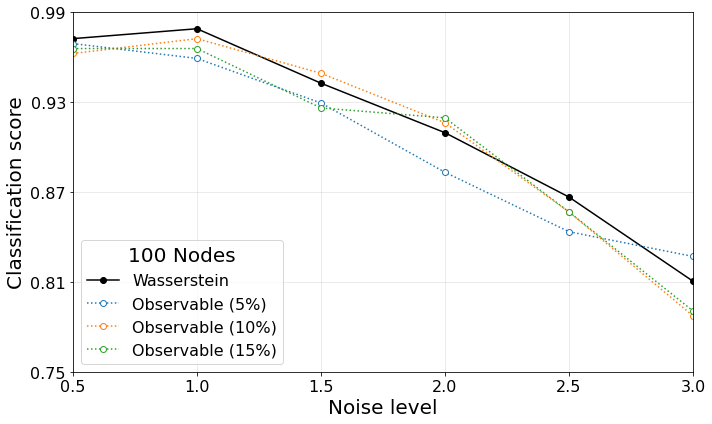

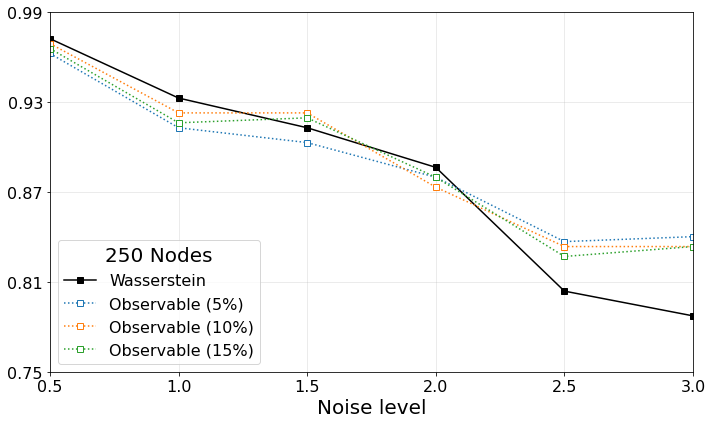

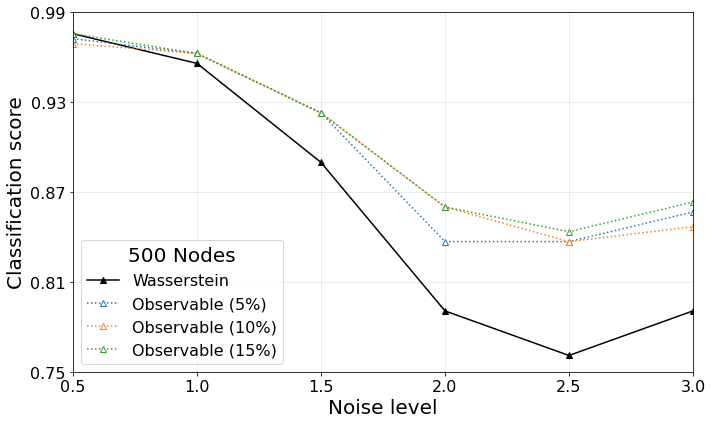

In [227]:
import matplotlib.pyplot as plt
import numpy as np

fontsize = 20

# Marker per graph size
marker_cycle = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', '<', '>', 'h', 'p']
markers = {gs: marker_cycle[i % len(marker_cycle)]
           for i, gs in enumerate(graph_sizes)}

# Color per slice percentage
cmap = plt.get_cmap("tab10")
slice_colors = {p: cmap(i % 10)
                for i, p in enumerate(num_slices_percentages)}

# ============================================================
# Step 1: Compute global y-limits across ALL data
# ============================================================
y_min = float("inf")
y_max = float("-inf")

for gs in graph_sizes:
    x = noise_levels

    # Wasserstein
    y_wass = [results[gs]["wass class mean"][nl] for nl in x]
    y_min = min(y_min, min(y_wass))
    y_max = max(y_max, max(y_wass))

    # Observable
    for p in num_slices_percentages:
        y_obs = [results[gs]["obs class mean"][p][nl] for nl in x]
        y_min = min(y_min, min(y_obs))
        y_max = max(y_max, max(y_obs))

# Add small padding
padding = 0.05 * (y_max - y_min)
y_min -= padding
y_max += padding

# Optional: fixed y-ticks for consistency
yticks = np.linspace(y_min, y_max, 5)

# ============================================================
# Step 2: Plot one figure per graph size
# ============================================================
for gs in graph_sizes:
    plt.figure(figsize=figsize)

    m = markers[gs]
    x = noise_levels

    # --- Wasserstein ---
    y_wass = [results[gs]["wass class mean"][nl] for nl in x]
    plt.plot(
        x, y_wass,
        linestyle="-",
        marker=m,
        color="black",
        markerfacecolor="black",
        markeredgecolor="black",
        label="Wasserstein"
    )

    # --- Observable ---
    for p in num_slices_percentages:
        y_obs = [results[gs]["obs class mean"][p][nl] for nl in x]
        c = slice_colors[p]

        plt.plot(
            x, y_obs,
            linestyle=":",
            marker=m,
            color=c,
            markerfacecolor="white",
            markeredgecolor=c,
            label=f"Observable ({p:.0%})"
        )

    plt.xlabel("Noise level", fontsize=fontsize)
    
    if gs == 100 or gs==500:
        plt.ylabel("Classification score", fontsize=fontsize)

    # Apply consistent axis limits and ticks
    plt.ylim(y_min, y_max)
    plt.xlim(min(noise_levels), max(noise_levels))
    plt.yticks(yticks, fontsize=16)
    plt.xticks(fontsize=16)
    
    from matplotlib.ticker import FormatStrFormatter
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

#     plt.title(f"{gs} Nodes", fontsize=fontsize)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=16, loc='lower left', title=f"{gs} Nodes", title_fontsize=fontsize)

    plt.tight_layout()

    # Optional: save figure
    plt.savefig(f"classification_vs_noise_n{gs}.png", dpi=300)
    plt.show()

Plotting the compute times for the experiments above.

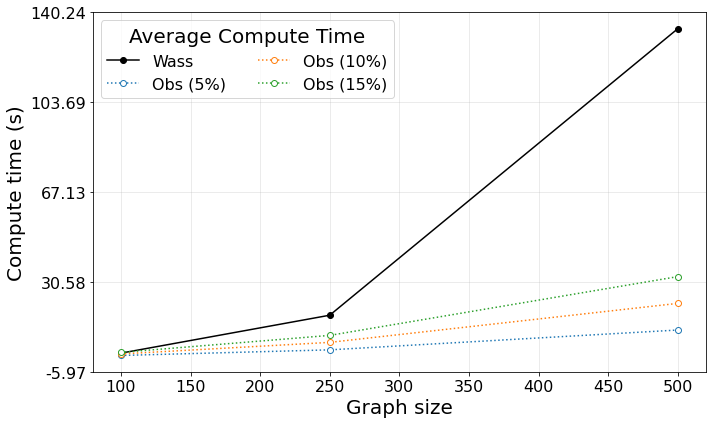

In [228]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FormatStrFormatter

# -----------------------
# 1) Aggregate avg compute times over noise levels
# -----------------------
# Assumes these already exist:
#   graph_sizes, noise_levels, num_slices_percentages, results, figsize

avg_times = {}  # avg_times[gs] = {"wass": float, "obs": {p: float}}

for gs in graph_sizes:
    # Wasserstein time mean: dict {noise_level: time}
    wass_times = [results[gs]["wass time mean"][nl] for nl in noise_levels]
    avg_wass = float(np.mean(wass_times))

    # Observable time mean: dict {p: {noise_level: time}}
    avg_obs = {}
    for p in num_slices_percentages:
        obs_times = [results[gs]["obs time mean"][p][nl] for nl in noise_levels]
        avg_obs[p] = float(np.mean(obs_times))

    avg_times[gs] = {"wass": avg_wass, "obs": avg_obs}

# -----------------------
# 2) Plot average compute time vs graph size (style similar to previous)
# -----------------------
fontsize = 20

# Color per slice percentage (same as before)
cmap = plt.get_cmap("tab10")
slice_colors = {p: cmap(i % 10) for i, p in enumerate(num_slices_percentages)}

# (Optional) compute global y-limits across all methods for consistent y-axis
all_y = []
all_y += [avg_times[gs]["wass"] for gs in graph_sizes]
for p in num_slices_percentages:
    all_y += [avg_times[gs]["obs"][p] for gs in graph_sizes]

y_min = float(min(all_y))
y_max = float(max(all_y))
padding = 0.05 * (y_max - y_min) if y_max > y_min else 1.0
y_min -= padding
y_max += padding
yticks = np.linspace(y_min, y_max, 5)

plt.figure(figsize=figsize)

x = graph_sizes

# --- Wasserstein (solid, black) ---
y_wass = [avg_times[gs]["wass"] for gs in x]
plt.plot(
    x, y_wass,
    linestyle="-",
    marker="o",
    color="black",
    markerfacecolor="black",
    markeredgecolor="black",
    label="Wass"
)

# --- Observable (dotted, colored by slice %) ---
for p in num_slices_percentages:
    y_obs = [avg_times[gs]["obs"][p] for gs in x]
    c = slice_colors[p]
    plt.plot(
        x, y_obs,
        linestyle=":",
        marker="o",
        color=c,
        markerfacecolor="white",
        markeredgecolor=c,
        label=f"Obs ({p:.0%})"
    )

plt.xlabel("Graph size", fontsize=fontsize)
plt.ylabel("Compute time (s)", fontsize=fontsize)
# plt.title("Average Compute Time vs Graph Size", fontsize=fontsize)

plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=16, title=f"Average Compute Time", title_fontsize=fontsize)

# Consistent y-axis range and ticks (and 2-decimal tick labels)
plt.ylim(y_min, y_max)
plt.yticks(yticks, fontsize=16)
plt.xticks(fontsize=16)
plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

plt.tight_layout()

# Optional: save
plt.savefig("avg_compute_time_vs_graph_size.png", dpi=300)

plt.show()